In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/student-gpa-prediction"

folders = [
    "data",
    "notebooks",
    "models",
    "src",
    "app",
    "docs"
]

for folder in folders:
    os.makedirs(f"{project_path}/{folder}", exist_ok=True)

Project folders created at: /content/drive/MyDrive/student-gpa-prediction


In [92]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

df = pd.read_csv("/kaggle/input/ai-impact-on-students/ai_student_impact_dataset (1).csv")

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

df.head()

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Shape : 50,000 rows × 16 columns


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.310,Copywriting/Drafting,Beginner,1,True,8.130,5,Allowed_With_Citation,6,2.393,86.440,High
1,100002,Medical,Junior,3.821,1.120,Ideation,Advanced,5,False,16.650,3,Allowed_With_Citation,9,3.696,69.390,Low
2,100003,Business,Freshman,3.398,21.260,Summarizing_Reading,Beginner,2,False,10.350,5,Strict_Ban,9,3.499,73.930,Medium
3,100004,Business,Senior,3.789,1.820,Copywriting/Drafting,Intermediate,4,False,15.230,2,Allowed_With_Citation,2,4.000,63.580,Medium
4,100005,STEM,Sophomore,3.635,9.290,Debugging/Troubleshooting,Advanced,4,False,12.550,4,Allowed_With_Citation,4,3.798,100.000,Medium


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn List:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Dataset Shape: (50000, 16)

Column List:
['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_

In [ ]:
missing_summary = df.isnull().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percentage"] = (missing_summary["missing_count"] / len(df)) * 100

duplicate_rows = df.duplicated().sum()
duplicate_student_id = df["Student_ID"].duplicated().sum() if "Student_ID" in df.columns else None

print("Duplicate Rows:", duplicate_rows)
print("Duplicate Student_ID:", duplicate_student_id)

missing_summary.sort_values("missing_count", ascending=False)

Duplicate Rows: 0
Duplicate Student_ID: 0


,column,missing_count,missing_percentage
0,Student_ID,0,0.000
1,Major_Category,0,0.000
2,Year_of_Study,0,0.000
3,Pre_Semester_GPA,0,0.000
4,Weekly_GenAI_Hours,0,0.000
5,Primary_Use_Case,0,0.000
6,Prompt_Engineering_Skill,0,0.000
7,Tool_Diversity,0,0.000
8,Paid_Subscription,0,0.000
9,Traditional_Study_Hours,0,0.000


In [ ]:
numeric_columns = [
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Skill_Retention_Score"
]

range_summary = df[numeric_columns].agg(["min", "max", "mean", "median", "std"]).T
range_summary

,min,max,mean,median,std
Pre_Semester_GPA,1.183,3.998,3.146,3.210,0.479
Post_Semester_GPA,1.000,4.000,3.349,3.421,0.496
Weekly_GenAI_Hours,0.000,40.000,8.428,5.800,8.269
Traditional_Study_Hours,1.000,35.860,11.209,11.180,5.156
Perceived_AI_Dependency,1.000,10.000,3.505,3.000,1.821
Anxiety_Level_During_Exams,1.000,10.000,4.271,4.000,2.144
Skill_Retention_Score,10.780,100.000,75.798,76.000,13.282


In [ ]:
df["GPA_Change"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

genai_bins = [0, 2, 5, 10, 15, 20, np.inf]
genai_labels = ["0-2", "2-5", "5-10", "10-15", "15-20", "20+"]

df["GenAI_Usage_Group"] = pd.cut(
    df["Weekly_GenAI_Hours"],
    bins=genai_bins,
    labels=genai_labels,
    include_lowest=True
)

df["Study_Balance_Ratio"] = df["Weekly_GenAI_Hours"] / (df["Traditional_Study_Hours"] + 1)

df[[
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "GPA_Change",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Study_Balance_Ratio",
    "GenAI_Usage_Group"
]].head()

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change,Weekly_GenAI_Hours,Traditional_Study_Hours,Study_Balance_Ratio,GenAI_Usage_Group
0,2.418,2.393,-0.025,23.310,8.130,2.553,20+
1,3.821,3.696,-0.125,1.120,16.650,0.063,0-2
2,3.398,3.499,0.101,21.260,10.350,1.873,20+
3,3.789,4.000,0.211,1.820,15.230,0.112,0-2
4,3.635,3.798,0.163,9.290,12.550,0.686,5-10


In [ ]:
kpi_summary = {
    "Total Students": len(df),
    "Average Pre-Semester GPA": df["Pre_Semester_GPA"].mean(),
    "Average Post-Semester GPA": df["Post_Semester_GPA"].mean(),
    "Average GPA Change": df["GPA_Change"].mean(),
    "Average Weekly GenAI Hours": df["Weekly_GenAI_Hours"].mean(),
    "Average Traditional Study Hours": df["Traditional_Study_Hours"].mean(),
    "Average AI Dependency": df["Perceived_AI_Dependency"].mean(),
    "Average Exam Anxiety": df["Anxiety_Level_During_Exams"].mean(),
    "Average Skill Retention": df["Skill_Retention_Score"].mean()
}

kpi_df = pd.DataFrame(kpi_summary.items(), columns=["Metric", "Value"])
kpi_df

,Metric,Value
0,Total Students,"50,000.000"
1,Average Pre-Semester GPA,3.146
2,Average Post-Semester GPA,3.349
3,Average GPA Change,0.203
4,Average Weekly GenAI Hours,8.428
5,Average Traditional Study Hours,11.209
6,Average AI Dependency,3.505
7,Average Exam Anxiety,4.271
8,Average Skill Retention,75.798


Students with GPA increase: 87.52%
Students with GPA decrease: 12.38%
Students with no GPA change: 0.10%


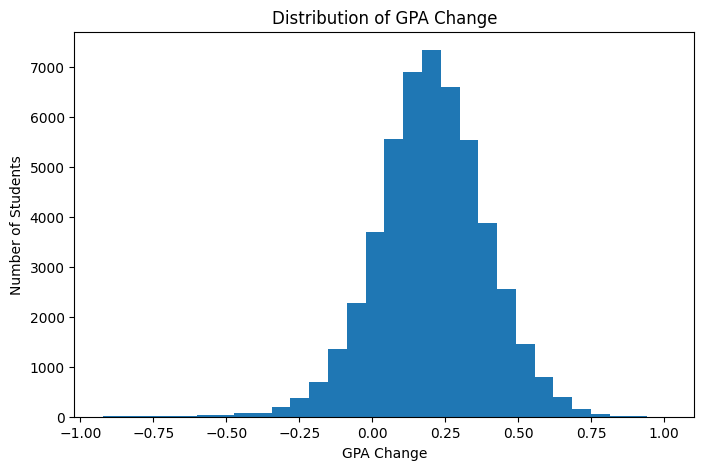

In [ ]:
gpa_distribution = df["GPA_Change"].describe().reset_index()
gpa_distribution.columns = ["Statistic", "Value"]

positive_gpa_rate = (df["GPA_Change"] > 0).mean() * 100
negative_gpa_rate = (df["GPA_Change"] < 0).mean() * 100
no_change_rate = (df["GPA_Change"] == 0).mean() * 100

print(f"Students with GPA increase: {positive_gpa_rate:.2f}%")
print(f"Students with GPA decrease: {negative_gpa_rate:.2f}%")
print(f"Students with no GPA change: {no_change_rate:.2f}%")

gpa_distribution

plt.figure(figsize=(8, 5))
plt.hist(df["GPA_Change"], bins=30)
plt.title("Distribution of GPA Change")
plt.xlabel("GPA Change")
plt.ylabel("Number of Students")
plt.show()

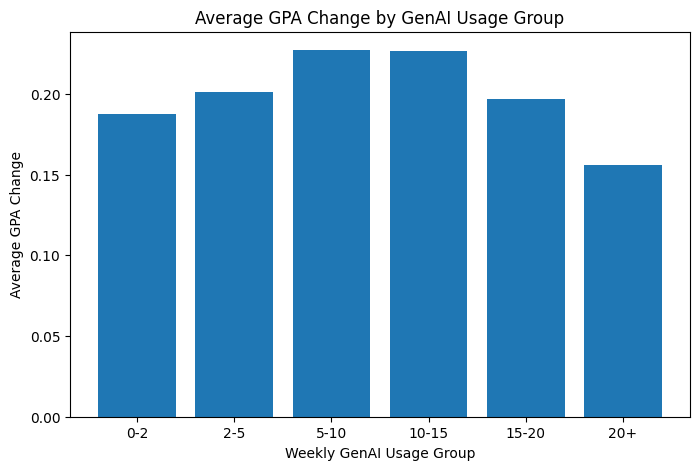

In [ ]:
genai_performance = df.groupby("GenAI_Usage_Group", observed=False).agg(
    students=("Student_ID", "count"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_ai_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean")
).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    genai_performance["GenAI_Usage_Group"].astype(str),
    genai_performance["avg_gpa_change"]
)
plt.title("Average GPA Change by GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average GPA Change")
plt.show()


In [ ]:
best_genai_group = genai_performance.loc[
    genai_performance["avg_gpa_change"].idxmax()
]

highest_dependency_group = genai_performance.loc[
    genai_performance["avg_ai_dependency"].idxmax()
]

print("Best GenAI Usage Group by GPA Change:")
print(best_genai_group)

print("\nHighest Dependency Group:")
print(highest_dependency_group)

Best GenAI Usage Group by GPA Change:
GenAI_Usage_Group       5-10
students               12173
avg_genai_hours        7.263
avg_gpa_change         0.227
avg_post_gpa           3.372
avg_ai_dependency      3.297
avg_anxiety            4.069
avg_skill_retention   77.079
Name: 2, dtype: object

Highest Dependency Group:
GenAI_Usage_Group        20+
students                5006
avg_genai_hours       27.805
avg_gpa_change         0.156
avg_post_gpa           3.299
avg_ai_dependency      6.366
avg_anxiety            5.621
avg_skill_retention   70.252
Name: 5, dtype: object


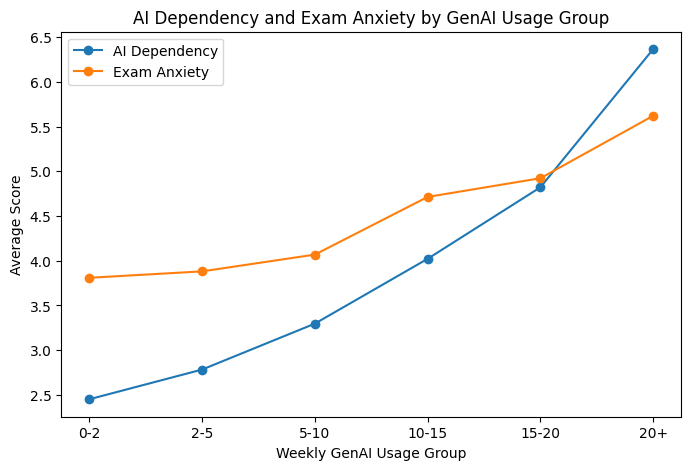

In [ ]:
risk_by_genai = df.groupby("GenAI_Usage_Group", observed=False).agg(
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    avg_burnout_students=("Burnout_Risk_Level", "count")
).reset_index()

plt.figure(figsize=(8, 5))
plt.plot(
    risk_by_genai["GenAI_Usage_Group"].astype(str),
    risk_by_genai["avg_dependency"],
    marker="o",
    label="AI Dependency"
)
plt.plot(
    risk_by_genai["GenAI_Usage_Group"].astype(str),
    risk_by_genai["avg_anxiety"],
    marker="o",
    label="Exam Anxiety"
)
plt.title("AI Dependency and Exam Anxiety by GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average Score")
plt.legend()
plt.show()

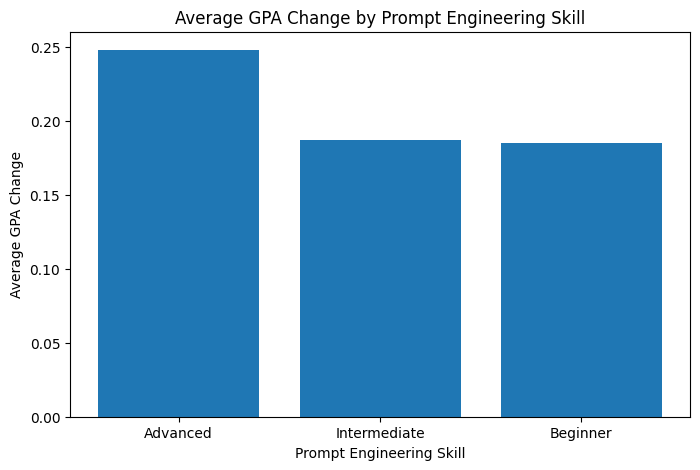

In [ ]:
prompt_skill_analysis = df.groupby("Prompt_Engineering_Skill").agg(
    students=("Student_ID", "count"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_ai_dependency=("Perceived_AI_Dependency", "mean")
).sort_values("avg_gpa_change", ascending=False).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    prompt_skill_analysis["Prompt_Engineering_Skill"],
    prompt_skill_analysis["avg_gpa_change"]
)
plt.title("Average GPA Change by Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Average GPA Change")
plt.show()

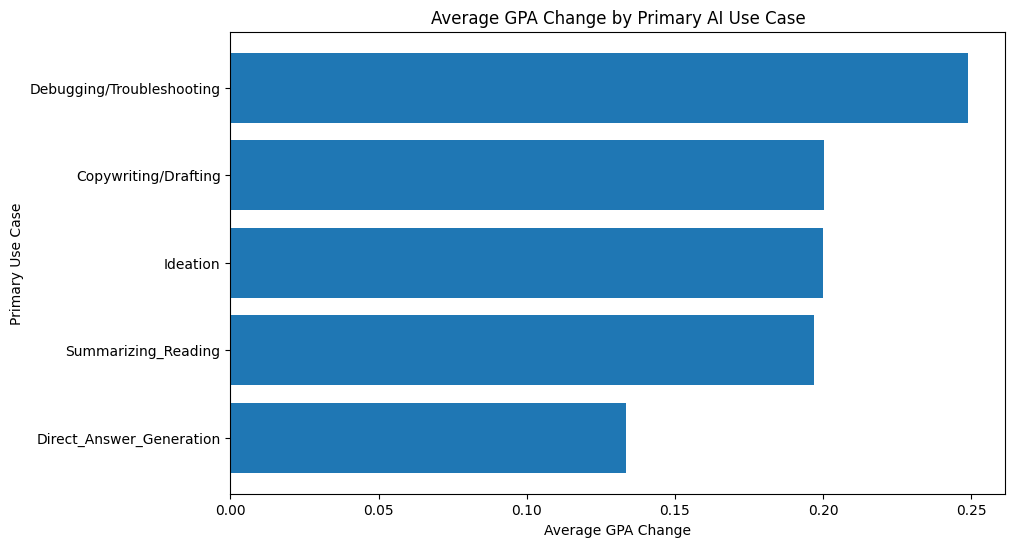

In [ ]:
use_case_analysis = df.groupby("Primary_Use_Case").agg(
    students=("Student_ID", "count"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean")
).sort_values("avg_gpa_change", ascending=False).reset_index()

plt.figure(figsize=(10, 6))
plt.barh(use_case_analysis["Primary_Use_Case"], use_case_analysis["avg_gpa_change"])
plt.title("Average GPA Change by Primary AI Use Case")
plt.xlabel("Average GPA Change")
plt.ylabel("Primary Use Case")
plt.gca().invert_yaxis()
plt.show()

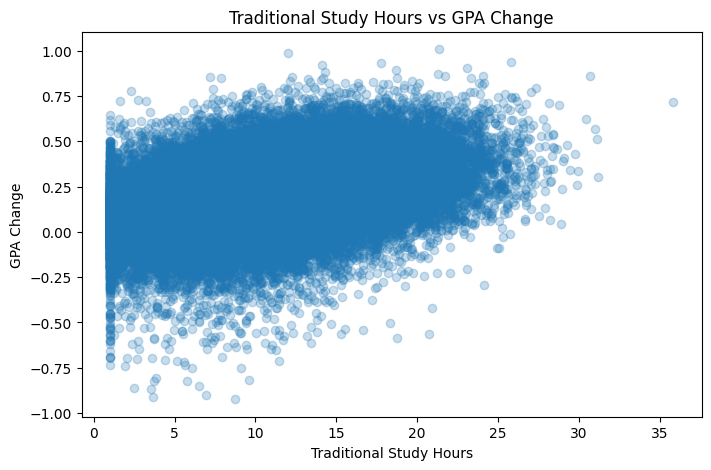

In [ ]:
study_correlation = df[[
    "Traditional_Study_Hours",
    "Weekly_GenAI_Hours",
    "GPA_Change",
    "Post_Semester_GPA",
    "Skill_Retention_Score"
]].corr()

plt.figure(figsize=(8, 5))
plt.scatter(
    df["Traditional_Study_Hours"],
    df["GPA_Change"],
    alpha=0.25
)
plt.title("Traditional Study Hours vs GPA Change")
plt.xlabel("Traditional Study Hours")
plt.ylabel("GPA Change")
plt.show()

In [ ]:
subscription_analysis = df.groupby("Paid_Subscription").agg(
    students=("Student_ID", "count"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean")
).reset_index()

subscription_gap = (
    subscription_analysis["avg_gpa_change"].max()
    - subscription_analysis["avg_gpa_change"].min()
)

print(f"GPA Change gap between subscription groups: {subscription_gap:.3f}")

GPA Change gap between subscription groups: 0.007


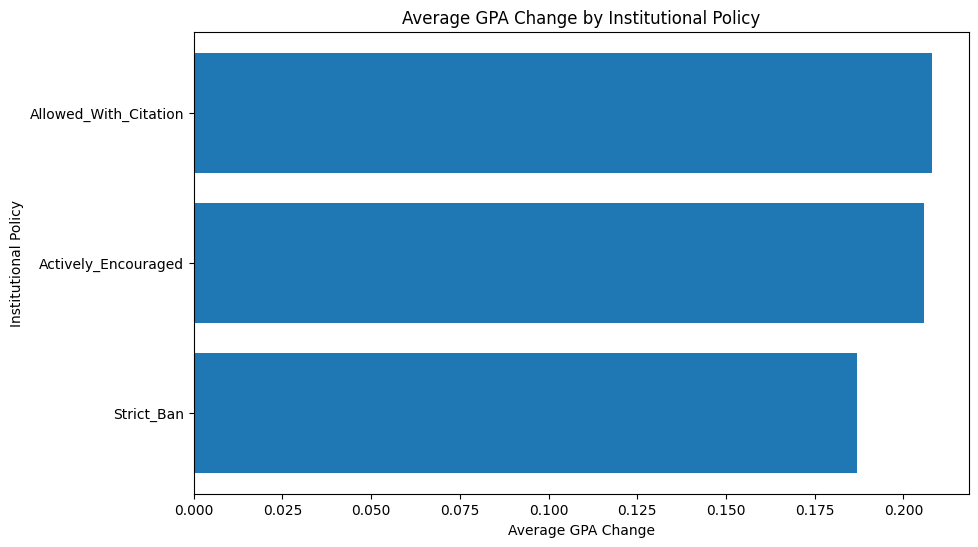

In [ ]:
policy_analysis = df.groupby("Institutional_Policy").agg(
    students=("Student_ID", "count"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean")
).sort_values("avg_gpa_change", ascending=False).reset_index()

plt.figure(figsize=(10, 6))
plt.barh(policy_analysis["Institutional_Policy"], policy_analysis["avg_gpa_change"])
plt.title("Average GPA Change by Institutional Policy")
plt.xlabel("Average GPA Change")
plt.ylabel("Institutional Policy")
plt.gca().invert_yaxis()
plt.show()

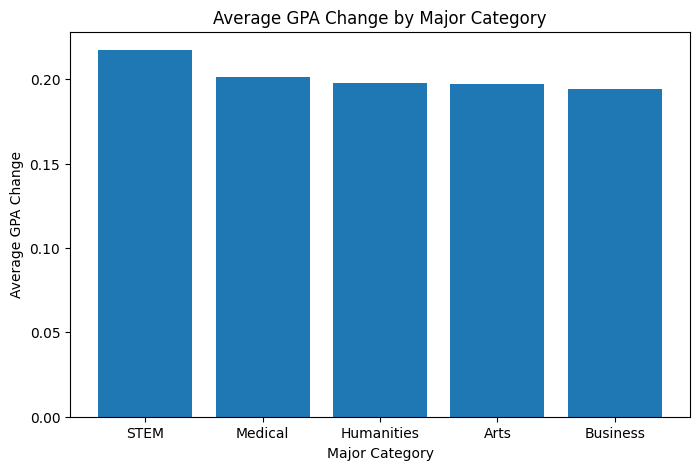

In [ ]:
major_analysis = df.groupby("Major_Category").agg(
    students=("Student_ID", "count"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_study=("Traditional_Study_Hours", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean")
).sort_values("avg_gpa_change", ascending=False).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(major_analysis["Major_Category"], major_analysis["avg_gpa_change"])
plt.title("Average GPA Change by Major Category")
plt.xlabel("Major Category")
plt.ylabel("Average GPA Change")
plt.show()

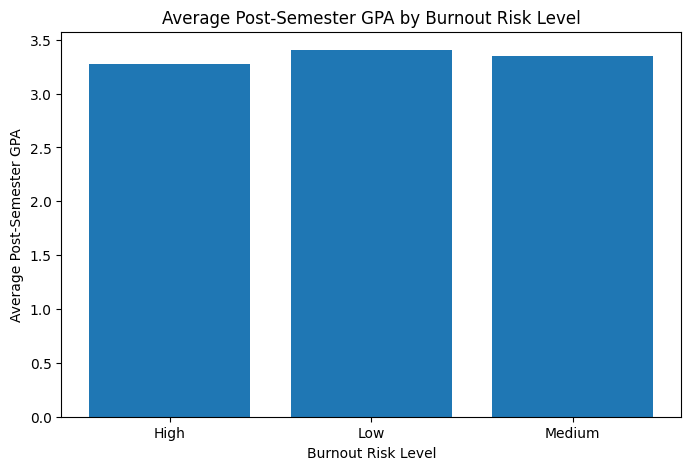

In [ ]:
burnout_analysis = df.groupby("Burnout_Risk_Level").agg(
    students=("Student_ID", "count"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean")
).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    burnout_analysis["Burnout_Risk_Level"],
    burnout_analysis["avg_post_gpa"]
)
plt.title("Average Post-Semester GPA by Burnout Risk Level")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Average Post-Semester GPA")
plt.show()

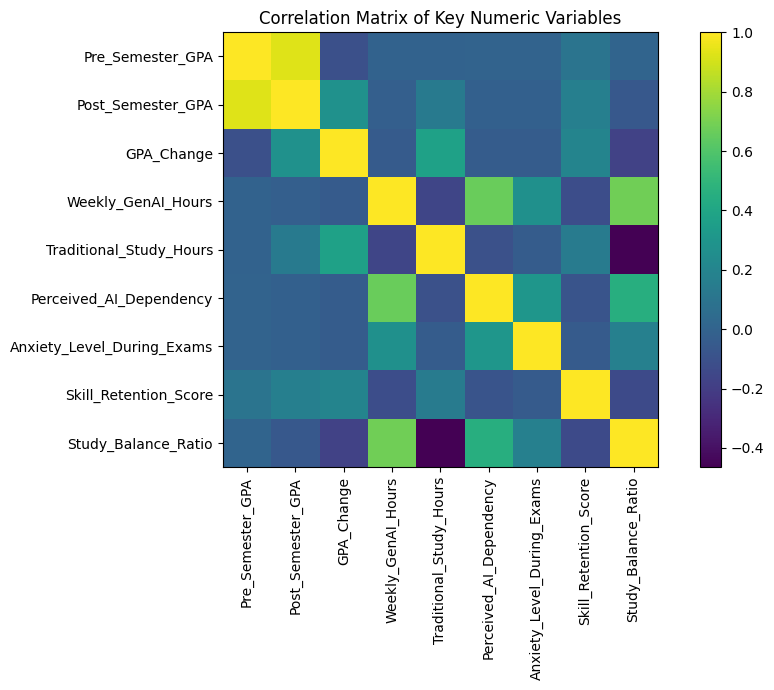

In [ ]:
correlation_columns = [
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "GPA_Change",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Skill_Retention_Score",
    "Study_Balance_Ratio"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=90)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.show()

In [ ]:
dependency_threshold = df["Perceived_AI_Dependency"].quantile(0.75)
anxiety_threshold = df["Anxiety_Level_During_Exams"].quantile(0.75)

df["High_Dependency_Flag"] = df["Perceived_AI_Dependency"] >= dependency_threshold
df["High_Anxiety_Flag"] = df["Anxiety_Level_During_Exams"] >= anxiety_threshold

df["Risk_Segment"] = np.select(
    [
        (df["High_Dependency_Flag"]) & (df["High_Anxiety_Flag"]),
        (df["High_Dependency_Flag"]) & (~df["High_Anxiety_Flag"]),
        (~df["High_Dependency_Flag"]) & (df["High_Anxiety_Flag"])
    ],
    [
        "High Dependency & High Anxiety",
        "High Dependency Only",
        "High Anxiety Only"
    ],
    default="Lower Risk"
)

risk_segment_analysis = df.groupby("Risk_Segment").agg(
    students=("Student_ID", "count"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean")
).sort_values("avg_gpa_change").reset_index()

risk_segment_analysis

,Risk_Segment,students,avg_genai_hours,avg_gpa_change,avg_post_gpa,avg_skill_retention
0,High Dependency & High Anxiety,5624,18.089,0.177,3.326,73.245
1,High Anxiety Only,8192,6.713,0.203,3.349,76.396
2,High Dependency Only,7787,14.471,0.205,3.353,75.049
3,Lower Risk,28397,5.352,0.208,3.353,76.337


In [ ]:
executive_summary = pd.DataFrame({
    "Insight Area": [
        "Overall GPA Performance",
        "Optimal GenAI Usage",
        "High GenAI Usage Risk",
        "Prompt Engineering Skill",
        "AI Use Case",
        "Traditional Study",
        "Paid Subscription",
        "Institutional Policy",
        "Major Category",
        "Burnout Risk"
    ],
    "Key Finding": [
        f"Average GPA increased by {df['GPA_Change'].mean():.3f}.",
        f"The best GenAI usage group is {best_genai_group['GenAI_Usage_Group']} with average GPA change of {best_genai_group['avg_gpa_change']:.3f}.",
        "Higher GenAI usage is associated with higher AI dependency and exam anxiety.",
        f"The highest GPA improvement is found in {prompt_skill_analysis.iloc[0]['Prompt_Engineering_Skill']} prompt skill group.",
        f"The strongest AI use case is {use_case_analysis.iloc[0]['Primary_Use_Case']} based on GPA change.",
        f"Traditional study hours have a correlation of {study_correlation.loc['Traditional_Study_Hours', 'GPA_Change']:.3f} with GPA change.",
        f"Paid subscription GPA change gap is only {subscription_gap:.3f}.",
        f"The best institutional policy group is {policy_analysis.iloc[0]['Institutional_Policy']}.",
        f"The highest GPA improvement major group is {major_analysis.iloc[0]['Major_Category']}.",
        "Higher burnout risk is associated with lower academic performance and retention."
    ],
    "Business Interpretation": [
        "Students generally improved academically during the semester.",
        "Moderate GenAI usage appears more effective than very low or excessive usage.",
        "Excessive AI usage may signal academic dependency and psychological risk.",
        "AI literacy matters, better prompting skills are linked to better outcomes.",
        "AI is more useful when supporting problem solving rather than replacing thinking.",
        "Traditional learning remains important and should not be replaced by AI.",
        "Paid tools alone do not guarantee better academic outcomes.",
        "Clear AI policies may be more effective than strict bans.",
        "Different academic fields may benefit from AI in different ways.",
        "Burnout monitoring is important when evaluating AI adoption."
    ]
})

executive_summary

,Insight Area,Key Finding,Business Interpretation
0,Overall GPA Performance,Average GPA increased by 0.203.,Students generally improved academically durin...
1,Optimal GenAI Usage,The best GenAI usage group is 5-10 with averag...,Moderate GenAI usage appears more effective th...
2,High GenAI Usage Risk,Higher GenAI usage is associated with higher A...,Excessive AI usage may signal academic depende...
3,Prompt Engineering Skill,The highest GPA improvement is found in Advanc...,"AI literacy matters, better prompting skills a..."
4,AI Use Case,The strongest AI use case is Debugging/Trouble...,AI is more useful when supporting problem solv...
5,Traditional Study,Traditional study hours have a correlation of ...,Traditional learning remains important and sho...
6,Paid Subscription,Paid subscription GPA change gap is only 0.007.,Paid tools alone do not guarantee better acade...
7,Institutional Policy,The best institutional policy group is Allowed...,Clear AI policies may be more effective than s...
8,Major Category,The highest GPA improvement major group is STEM.,Different academic fields may benefit from AI ...
9,Burnout Risk,Higher burnout risk is associated with lower a...,Burnout monitoring is important when evaluatin...
